<a href="https://oscar-defelice.github.io">
<img src="../../img/image.png" height="125" align="right" />
</a>

# TP 03-B — Logistic Regression for Text Classification

**Course:** Natural Language Processing  
**Session:** 3 / 8  
**Duration:** ~40 min

---

## Objectives

By the end of this session you will be able to:

- Train a Logistic Regression classifier on TF-IDF features with sklearn
- Understand and tune the regularisation parameter C
- Inspect the weight vectors to understand what the model has learned
- Compare LR against your best Naive Bayes from TP-A
- Bonus: implement gradient descent on a toy problem from scratch

---

## Roadmap

| Part | Task | Deliverable |
|------|------|-------------|
| 1 | Data loading (same split as TP-A) | Shared preprocessing |
| 2 | Baseline LR with sklearn | F1, confusion matrix |
| 3 | Regularisation sweep | Accuracy vs C plot |
| 4 | Feature analysis — learned weights | Top weights per class |
| 5 | NB vs LR comparison | Summary table |
| Bonus | Sigmoid + gradient descent from scratch | Mini implementation |

Each part ends with a **📝 Your analysis** cell.

In [7]:
import re
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")
sns.set_style("darkgrid")
SEED = 42
np.random.seed(SEED)
AG_NEWS_LABELS = {1: "World", 2: "Sports", 3: "Business", 4: "Sci/Tech"}
print("Imports OK")

Imports OK


---

## Part 1 — Data loading

**Important:** use the same preprocessing function and the same `SEED` as in TP-A.
The split must be identical so that comparisons between NB and LR are valid.

In [8]:
def preprocess_text(text: str) -> str:
    """Minimal 5-step text normalisation pipeline.

    Parameters
    ----------
    text : str
        Raw input string.

    Returns
    -------
    str
        Normalised string.
    """
    text = text.lower()
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"[^a-z0-9 ]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def load_ag_news(
    val_size: float = 0.1,
    seed: int = SEED,
) -> tuple[list[str], list[str], list[str], list[int], list[int], list[int]]:
    """Load AG News, preprocess, and split into train/val/test.

    Parameters
    ----------
    val_size : float
        Fraction of training data used for validation.
    seed : int
        Random seed for reproducibility.

    Returns
    -------
    tuple
        (train_texts, val_texts, test_texts, train_labels, val_labels, test_labels)
    """
    raw = load_dataset("ag_news")
    rng = np.random.default_rng(seed)

    train_texts_raw = [r["text"] for r in raw["train"]]
    train_labels_raw = [r["label"] for r in raw["train"]]
    test_texts = [preprocess_text(r["text"]) for r in raw["test"]]
    test_labels = [r["label"] for r in raw["test"]]

    n = len(train_texts_raw)
    idx = rng.permutation(n)
    split = int(n * (1 - val_size))
    train_idx, val_idx = idx[:split], idx[split:]

    train_texts  = [preprocess_text(train_texts_raw[i]) for i in train_idx]
    train_labels = [train_labels_raw[i]                 for i in train_idx]
    val_texts    = [preprocess_text(train_texts_raw[i]) for i in val_idx]
    val_labels   = [train_labels_raw[i]                 for i in val_idx]

    return train_texts, val_texts, test_texts, train_labels, val_labels, test_labels


train_texts, val_texts, test_texts, train_labels, val_labels, test_labels = load_ag_news()
label_names = [AG_NEWS_LABELS[i + 1] for i in range(4)]
print(f"Train: {len(train_texts):,}  Val: {len(val_texts):,}  Test: {len(test_texts):,}")

Train: 108,000  Val: 12,000  Test: 7,600


---

## Part 2 — Baseline Logistic Regression

Build a pipeline: `TfidfVectorizer` → `LogisticRegression`.

Key parameters to be aware of:
- `C`: inverse regularisation strength (larger C = less regularisation)
- `solver='lbfgs'`: efficient for multi-class problems with dense features
- `multi_class='multinomial'`: uses softmax instead of one-vs-rest
- `max_iter=1000`: LR may need more iterations than the default (100)

### 2.1 — Implement `build_lr_pipeline`

In [9]:
def build_lr_pipeline(
    C: float = 1.0,
    penalty: str = "l2",
    vectorizer: str = "tfidf",
    max_features: int | None = 50_000,
    ngram_range: tuple[int, int] = (1, 1),
    max_iter: int = 1000,
) -> Pipeline:
    """Build a sklearn Pipeline: TF-IDF → LogisticRegression."""
    if vectorizer == "tfidf":
        vect = TfidfVectorizer(max_features=max_features, ngram_range=ngram_range)
    elif vectorizer == "count":
        vect = CountVectorizer(max_features=max_features, ngram_range=ngram_range)
    else:
        raise ValueError(f"Unknown vectorizer: {vectorizer}")

    # saga is the only solver that supports L1 multinomial, but converges
    # very slowly on sparse high-dim TF-IDF: relax tol so it stops at a
    # reasonable optimum instead of grinding for 10+ minutes.
    solver = "saga" if penalty == "l1" else "lbfgs"
    tol = 1e-2 if penalty == "l1" else 1e-4
    clf = LogisticRegression(
        C=C,
        penalty=penalty,
        solver=solver,
        max_iter=max_iter,
        tol=tol,
        random_state=SEED,
        n_jobs=-1,
    )
    return Pipeline([("vect", vect), ("clf", clf)])


def evaluate_classifier(
    y_true: list[int],
    y_pred: np.ndarray,
    label_names: list[str],
    title: str = "Evaluation",
) -> dict[str, float]:
    """Print classification report and plot confusion matrix."""
    report = classification_report(
        y_true, y_pred, target_names=label_names, output_dict=True
    )
    print(f"\n{'='*60}\n  {title}\n{'='*60}")
    print(classification_report(y_true, y_pred, target_names=label_names))

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(cm, display_labels=label_names).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

    return {"accuracy": report["accuracy"], "macro_f1": report["macro avg"]["f1-score"]}


  LR (TF-IDF, C=1.0, L2) — validation
              precision    recall  f1-score   support

       World       0.93      0.89      0.91      3027
      Sports       0.95      0.98      0.97      2961
    Business       0.89      0.88      0.89      3000
    Sci/Tech       0.89      0.91      0.90      3012

    accuracy                           0.92     12000
   macro avg       0.92      0.92      0.92     12000
weighted avg       0.92      0.92      0.92     12000



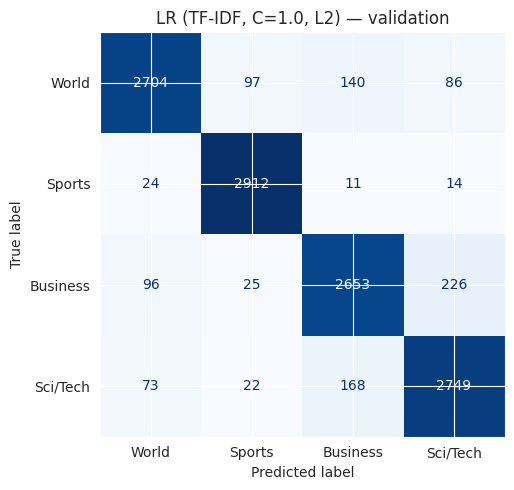

In [10]:
# ── Train and evaluate baseline LR ────────────────────────────────────────────
pipe_lr = build_lr_pipeline(C=1.0)
pipe_lr.fit(train_texts, train_labels)
val_pred_lr = pipe_lr.predict(val_texts)

results_lr = evaluate_classifier(
    val_labels, val_pred_lr, label_names,
    title="LR (TF-IDF, C=1.0, L2) — validation",
)

📝 **Your analysis (2.1)**

1. LR macro F1 = **0.92** on val, vs best NB ≈ 0.908 → LR wins by ~1 point.
2. Hardest class: **Business** (F1 = 0.89). Same ranking as NB.
3. Main confusion: **Business ↔ Sci/Tech** — both share corporate/tech vocabulary (company, market, tech). World ↔ Business also non-trivial (oil, economy).

---

## Part 3 — Regularisation sweep

The parameter C controls regularisation:
- Small C → strong regularisation → simpler model (high bias, low variance)
- Large C → weak regularisation → complex model (low bias, high variance)

### 3.1 — L2 sweep

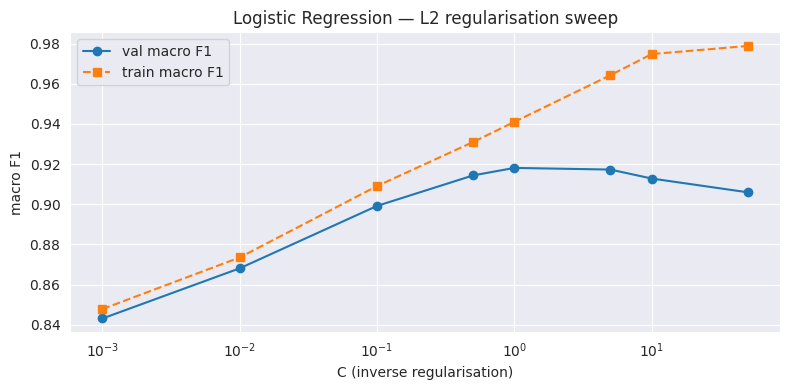

Best C = 1.0
     C  val_accuracy  val_macro_f1  train_macro_f1
 0.001      0.844667      0.843151        0.847853
 0.010      0.868917      0.868150        0.873559
 0.100      0.899417      0.899218        0.909112
 0.500      0.914417      0.914397        0.931021
 1.000      0.918167      0.918134        0.941078
 5.000      0.917250      0.917309        0.964311
10.000      0.912750      0.912841        0.974819
50.000      0.905833      0.905988        0.978860


In [11]:
def regularisation_sweep(
    C_values: list[float],
    train_texts: list[str],
    train_labels: list[int],
    val_texts: list[str],
    val_labels: list[int],
    penalty: str = "l2",
) -> pd.DataFrame:
    """Evaluate LogisticRegression across a range of regularisation strengths."""
    rows = []
    for C in C_values:
        pipe = build_lr_pipeline(C=C, penalty=penalty)
        pipe.fit(train_texts, train_labels)
        val_pred = pipe.predict(val_texts)
        train_pred = pipe.predict(train_texts)
        val_rep = classification_report(val_labels, val_pred, output_dict=True)
        train_rep = classification_report(train_labels, train_pred, output_dict=True)
        rows.append({
            "C": C,
            "val_accuracy": val_rep["accuracy"],
            "val_macro_f1": val_rep["macro avg"]["f1-score"],
            "train_macro_f1": train_rep["macro avg"]["f1-score"],
        })
    return pd.DataFrame(rows)


C_values = [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0]
sweep_df = regularisation_sweep(
    C_values, train_texts, train_labels, val_texts, val_labels, penalty="l2"
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(sweep_df["C"], sweep_df["val_macro_f1"],   marker="o", label="val macro F1")
ax.semilogx(sweep_df["C"], sweep_df["train_macro_f1"], marker="s", linestyle="--", label="train macro F1")
ax.set_xlabel("C (inverse regularisation)")
ax.set_ylabel("macro F1")
ax.set_title("Logistic Regression — L2 regularisation sweep")
ax.legend()
plt.tight_layout()
plt.show()

best_C = sweep_df.loc[sweep_df["val_macro_f1"].idxmax(), "C"]
print(f"Best C = {best_C}")
print(sweep_df.to_string(index=False))

### 3.2 — L1 vs L2 comparison

L1 regularisation produces sparse models (many weights = 0). This is interesting for NLP:
it effectively selects a subset of features.

In [12]:
def compare_penalties(
    C: float,
    train_texts: list[str],
    train_labels: list[int],
    val_texts: list[str],
    val_labels: list[int],
) -> pd.DataFrame:
    """Compare L1 and L2 regularisation for Logistic Regression."""
    rows = []
    for penalty in ["l1", "l2"]:
        pipe = build_lr_pipeline(C=C, penalty=penalty)
        pipe.fit(train_texts, train_labels)
        val_pred = pipe.predict(val_texts)
        rep = classification_report(val_labels, val_pred, output_dict=True)
        coef = pipe[1].coef_
        n_zero = int((coef == 0).sum())
        sparsity = n_zero / coef.size
        rows.append({
            "penalty": penalty,
            "val_macro_f1": rep["macro avg"]["f1-score"],
            "n_zero_weights": n_zero,
            "sparsity": sparsity,
        })
    return pd.DataFrame(rows)


penalty_df = compare_penalties(
    best_C, train_texts, train_labels, val_texts, val_labels
)
print(penalty_df.to_string(index=False))

penalty  val_macro_f1  n_zero_weights  sparsity
     l1      0.910808          193910   0.96955
     l2      0.918134               0   0.00000


📝 **Your analysis (3)**

1. Optimal **C = 1.0** (val F1 = 0.918). Very small C (0.001) → strong shrinkage, underfitting: train ≈ val ≈ 0.84. Very large C (50) → near-zero regularisation, overfit: train F1 = 0.979 but val drops to 0.906.
2. Train and val diverge from **C ≥ 1**: train keeps climbing toward 0.98 while val plateaus then decreases — textbook overfitting onset.
3. L1 sparsity = **96.96 %** (193 910 / 200 000 weights = 0) → only ~3 % of features (~6 k) are actually used.
4. **L2 slightly better** (0.918 vs 0.911). Not surprising: in text, many near-synonymous features carry small bits of useful signal; L1 kills them outright while L2 just shrinks them, keeping the ensemble effect.

---

## Part 4 — Feature analysis: learned weights

Unlike Naive Bayes (which stores log-probabilities), Logistic Regression stores
a weight matrix of shape `(n_classes, vocab_size)`. A large positive weight for
class c means that word strongly predicts class c.


World — top 10 positive:
       word   weight direction
        afp 7.820533         +
       iraq 6.153644         +
      iraqi 4.806386         +
    nuclear 4.718330         +
         un 4.494323         +
     arafat 4.480617         +
  president 4.326747         +
       iran 4.285521         +
palestinian 4.277523         +
   military 4.163638         +

Sports — top 10 positive:
    word   weight direction
     cup 6.606836         +
   coach 6.515474         +
  sports 6.073235         +
  league 5.704624         +
    team 5.169032         +
 olympic 5.054764         +
baseball 4.908882         +
 stadium 4.692398         +
  season 4.547124         +
 players 4.481754         +

Business — top 10 positive:
     word   weight direction
  economy 4.738332         +
      oil 4.646079         +
   hellip 4.499893         +
fullquote 4.472952         +
     bank 4.338457         +
 economic 4.262717         +
      tax 4.162430         +
      inc 3.938299         +
 airline

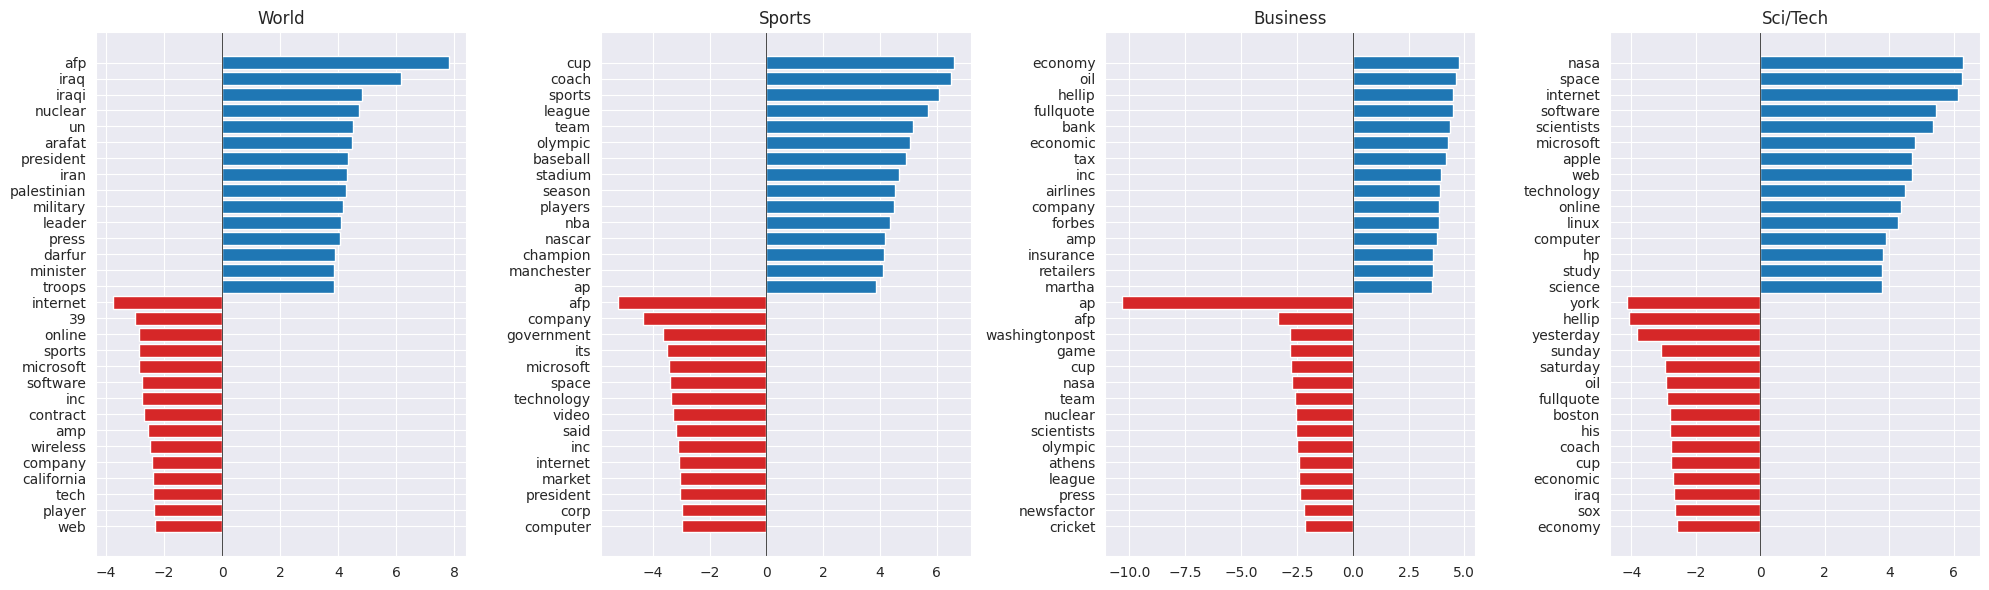

In [13]:
def top_weights_per_class(
    pipeline: Pipeline,
    label_names: list[str],
    n: int = 20,
) -> dict[str, pd.DataFrame]:
    """Extract the n words with the largest positive and negative weights per class."""
    vocab = pipeline[0].get_feature_names_out()
    coef = pipeline[1].coef_
    out = {}
    for i, name in enumerate(label_names):
        w = coef[i]
        top_pos_idx = np.argsort(w)[::-1][:n]
        top_neg_idx = np.argsort(w)[:n]
        pos_df = pd.DataFrame({
            "word": vocab[top_pos_idx],
            "weight": w[top_pos_idx],
            "direction": "+",
        })
        neg_df = pd.DataFrame({
            "word": vocab[top_neg_idx],
            "weight": w[top_neg_idx],
            "direction": "-",
        })
        out[name] = pd.concat([pos_df, neg_df], ignore_index=True)
    return out


def plot_top_weights(
    weights: dict[str, pd.DataFrame],
    n_plot: int = 15,
) -> None:
    """Horizontal bar plot of top positive and negative weights per class."""
    n_classes = len(weights)
    fig, axes = plt.subplots(1, n_classes, figsize=(5 * n_classes, 6))
    if n_classes == 1:
        axes = [axes]
    for ax, (name, df) in zip(axes, weights.items()):
        pos = df[df["direction"] == "+"].head(n_plot)
        neg = df[df["direction"] == "-"].head(n_plot)
        combined = pd.concat([neg.iloc[::-1], pos.iloc[::-1]], ignore_index=True)
        colors = ["#d62728" if w < 0 else "#1f77b4" for w in combined["weight"]]
        ax.barh(combined["word"], combined["weight"], color=colors)
        ax.set_title(name)
        ax.axvline(0, color="black", linewidth=0.5)
    plt.tight_layout()
    plt.show()


pipe_best = build_lr_pipeline(C=best_C)
pipe_best.fit(train_texts, train_labels)
weights = top_weights_per_class(pipe_best, label_names, n=20)

for name, df in weights.items():
    print(f"\n{name} — top 10 positive:")
    print(df[df["direction"] == "+"].head(10).to_string(index=False))

plot_top_weights(weights)

### 4.2 — Compare NB informativeness scores vs LR weights

Do NB and LR agree on which words are most discriminative?

In [14]:
from sklearn.naive_bayes import MultinomialNB


def most_informative_features_nb(
    pipeline: Pipeline,
    label_names: list[str],
    n: int = 20,
) -> dict[str, pd.DataFrame]:
    """Compute log-prob differences per class for a fitted NB pipeline."""
    vocab = pipeline[0].get_feature_names_out()
    log_prob = pipeline[1].feature_log_prob_
    out = {}
    for i, name in enumerate(label_names):
        other = np.delete(log_prob, i, axis=0).mean(axis=0)
        score = log_prob[i] - other
        top_idx = np.argsort(score)[::-1][:n]
        out[name] = pd.DataFrame({
            "word": vocab[top_idx],
            "score": score[top_idx],
        })
    return out


def compare_nb_lr_features(
    nb_features: dict[str, pd.DataFrame],
    lr_weights: dict[str, pd.DataFrame],
    class_name: str,
    top_k: int = 20,
) -> pd.DataFrame:
    """Compute overlap between top-k NB and LR features for one class."""
    nb_df = nb_features[class_name].head(top_k)
    lr_df = lr_weights[class_name][lr_weights[class_name]["direction"] == "+"].head(top_k)
    nb_words = set(nb_df["word"])
    lr_words = set(lr_df["word"])
    all_words = nb_words | lr_words
    nb_score_map = dict(zip(nb_df["word"], nb_df["score"]))
    lr_weight_map = dict(zip(lr_df["word"], lr_df["weight"]))
    rows = []
    for w in all_words:
        rows.append({
            "word": w,
            "in_nb": w in nb_words,
            "in_lr": w in lr_words,
            "nb_score": nb_score_map.get(w, np.nan),
            "lr_weight": lr_weight_map.get(w, np.nan),
        })
    return pd.DataFrame(rows).sort_values(
        ["in_nb", "in_lr", "nb_score"], ascending=[False, False, False]
    ).reset_index(drop=True)


nb_pipe = Pipeline([
    ("vect", TfidfVectorizer(max_features=50_000)),
    ("clf", MultinomialNB(alpha=0.1)),
])
nb_pipe.fit(train_texts, train_labels)
nb_features = most_informative_features_nb(nb_pipe, label_names, n=20)

comparison = compare_nb_lr_features(nb_features, weights, class_name="Sports")
print(comparison.to_string(index=False))
overlap = (comparison["in_nb"] & comparison["in_lr"]).sum()
print(f"\nOverlap (top-20, Sports): {overlap}/20")

        word  in_nb  in_lr  nb_score  lr_weight
 quarterback   True   True  6.238205   3.748577
      nascar   True   True  5.586821   4.172965
      pacers   True  False  5.980066        NaN
   preseason   True  False  5.900648        NaN
      knicks   True  False  5.871483        NaN
    steelers   True  False  5.798331        NaN
     pistons   True  False  5.790724        NaN
  touchdowns   True  False  5.778148        NaN
       notre   True  False  5.740691        NaN
      wenger   True  False  5.734445        NaN
    phillies   True  False  5.722222        NaN
   cavaliers   True  False  5.703679        NaN
     broncos   True  False  5.687556        NaN
        ncaa   True  False  5.659853        NaN
diamondbacks   True  False  5.659567        NaN
    coaching   True  False  5.659502        NaN
        dame   True  False  5.644819        NaN
  linebacker   True  False  5.587705        NaN
         mvp   True  False  5.560477        NaN
        zook   True  False  5.530776    

📝 **Your analysis (4)**

1. Top positive weights are clean and semantic: *iraq/un/arafat* (World), *cup/coach/league* (Sports), *economy/bank/oil* (Business), *nasa/space/microsoft* (Sci/Tech). A few corpus artefacts: `afp`, `hellip`, `fullquote`.
2. Top negatives for Sports = top positives of the other classes (softmax coupling): pushing one class up pushes others down.
3. NB vs LR overlap = **2/20**. NB favours rare class-pure tokens (team names: *pacers, knicks, steelers*), LR favours frequent generic ones (*cup, team, season*) that maximise margin across many docs.

---

## Part 5 — NB vs LR comparison + n-gram ablation

Bring together the results from both TPs into one comparison table.

In [15]:
def full_ablation(
    train_texts: list[str],
    train_labels: list[int],
    val_texts: list[str],
    val_labels: list[int],
    best_C: float,
    best_nb_alpha: float = 0.1,
) -> pd.DataFrame:
    """Run all model/feature combinations and collect validation metrics."""
    from sklearn.naive_bayes import MultinomialNB

    def nb_pipe(vec):
        return Pipeline([("vect", vec), ("clf", MultinomialNB(alpha=best_nb_alpha))])

    def lr_pipe(vec):
        return Pipeline([
            ("vect", vec),
            ("clf", LogisticRegression(C=best_C, max_iter=1000, n_jobs=-1, random_state=SEED)),
        ])

    configs = [
        ("NB | count unigrams",  nb_pipe(CountVectorizer(max_features=50_000))),
        ("NB | tfidf unigrams",  nb_pipe(TfidfVectorizer(max_features=50_000))),
        ("NB | tfidf bigrams",   nb_pipe(TfidfVectorizer(max_features=50_000, ngram_range=(1, 2)))),
        ("LR | tfidf unigrams",  lr_pipe(TfidfVectorizer(max_features=50_000))),
        ("LR | tfidf bigrams",   lr_pipe(TfidfVectorizer(max_features=50_000, ngram_range=(1, 2)))),
    ]

    rows = []
    for label, pipe in configs:
        pipe.fit(train_texts, train_labels)
        preds = pipe.predict(val_texts)
        report = classification_report(val_labels, preds, output_dict=True)
        rows.append({
            "model": label.split("|")[0].strip(),
            "features": label.split("|")[1].strip() if "|" in label else "",
            "val_macro_f1": round(report["macro avg"]["f1-score"], 4),
            "val_accuracy": round(report["accuracy"], 4),
        })
    return pd.DataFrame(rows).sort_values("val_macro_f1", ascending=False)


abl_df = full_ablation(train_texts, train_labels, val_texts, val_labels, best_C=best_C)
print(abl_df.to_string(index=False))

model       features  val_macro_f1  val_accuracy
   LR  tfidf bigrams        0.9185        0.9185
   LR tfidf unigrams        0.9181        0.9182
   NB tfidf unigrams        0.9080        0.9080
   NB count unigrams        0.9061        0.9062
   NB  tfidf bigrams        0.9041        0.9042


📝 **Your analysis (5)**

1. Best: **LR + TF-IDF bigrams**, F1 = 0.9185. LR beats NB by ~1 pt at every feature set.
2. Bigrams: negligible for LR (+0.0004), **hurt** NB (−0.004). L2 absorbs the noise; NB's independence assumption suffers from sparse bigram estimates.
3. Best tradeoff: **LR + TF-IDF unigrams** (0.9181) — same F1 as bigrams, ~10× smaller vocab.

---

## Part 6 — Final test evaluation

Evaluate your best LR configuration on the test set (once, no further tuning).


  LR (TF-IDF bigrams, C=1.0) — test
              precision    recall  f1-score   support

       World       0.93      0.90      0.92      1900
      Sports       0.95      0.98      0.96      1900
    Business       0.89      0.89      0.89      1900
    Sci/Tech       0.90      0.90      0.90      1900

    accuracy                           0.92      7600
   macro avg       0.92      0.92      0.92      7600
weighted avg       0.92      0.92      0.92      7600



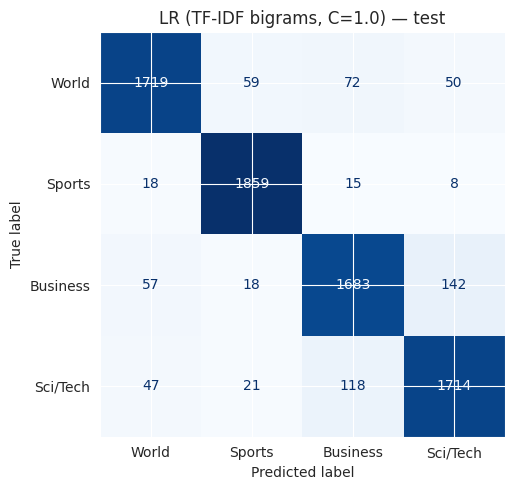

In [16]:
pipe_final = build_lr_pipeline(C=best_C, ngram_range=(1, 2))
pipe_final.fit(train_texts, train_labels)
test_pred = pipe_final.predict(test_texts)
results_test = evaluate_classifier(
    test_labels, test_pred, label_names,
    title=f"LR (TF-IDF bigrams, C={best_C}) — test",
)

---

## Bonus — Gradient descent from scratch

Implement gradient descent for binary logistic regression on a 2D synthetic dataset.
This is a simplified version of what sklearn does internally.

The goal is to gain intuition for:
- How the sigmoid maps scores to probabilities
- How the weight update moves the decision boundary
- How learning rate η affects convergence

In [17]:
# ── Synthetic 2D dataset ──────────────────────────────────────────────────────
rng = np.random.default_rng(SEED)
n_pos, n_neg = 200, 200
X_pos = rng.multivariate_normal([2, 2], [[1, 0.5], [0.5, 1]], n_pos)
X_neg = rng.multivariate_normal([-2, -2], [[1, -0.3], [-0.3, 1]], n_neg)

X = np.vstack([X_pos, X_neg]).astype(np.float64)
y = np.array([1] * n_pos + [0] * n_neg)

shuffle_idx = rng.permutation(len(y))
X, y = X[shuffle_idx], y[shuffle_idx]

# Add bias column
X_bias = np.hstack([np.ones((len(X), 1)), X])
print(f"X shape: {X_bias.shape}, y shape: {y.shape}")

X shape: (400, 3), y shape: (400,)


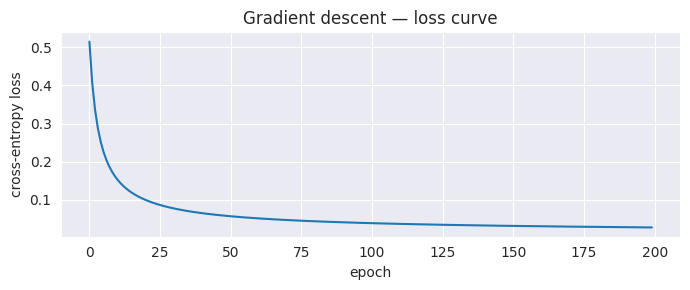

Training accuracy: 0.9950


In [18]:
def sigmoid(z: np.ndarray) -> np.ndarray:
    """Compute the sigmoid function element-wise."""
    return np.where(
        z >= 0,
        1.0 / (1.0 + np.exp(-z)),
        np.exp(z) / (1.0 + np.exp(z)),
    )


def cross_entropy_loss(
    y_true: np.ndarray,
    y_pred: np.ndarray,
) -> float:
    """Compute binary cross-entropy loss."""
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
    return float(-np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred)))


def gradient_descent_lr(
    X: np.ndarray,
    y: np.ndarray,
    learning_rate: float = 0.1,
    n_epochs: int = 200,
) -> tuple[np.ndarray, list[float]]:
    """Train binary logistic regression via gradient descent."""
    N, D = X.shape
    w = np.zeros(D)
    losses = []
    for _ in range(n_epochs):
        y_hat = sigmoid(X @ w)
        grad = (X.T @ (y_hat - y)) / N
        w = w - learning_rate * grad
        losses.append(cross_entropy_loss(y, sigmoid(X @ w)))
    return w, losses


w_learned, losses = gradient_descent_lr(X_bias, y, learning_rate=0.1, n_epochs=200)

plt.figure(figsize=(7, 3))
plt.plot(losses)
plt.xlabel("epoch")
plt.ylabel("cross-entropy loss")
plt.title("Gradient descent — loss curve")
plt.tight_layout()
plt.show()

y_pred_binary = (sigmoid(X_bias @ w_learned) >= 0.5).astype(int)
acc = (y_pred_binary == y).mean()
print(f"Training accuracy: {acc:.4f}")

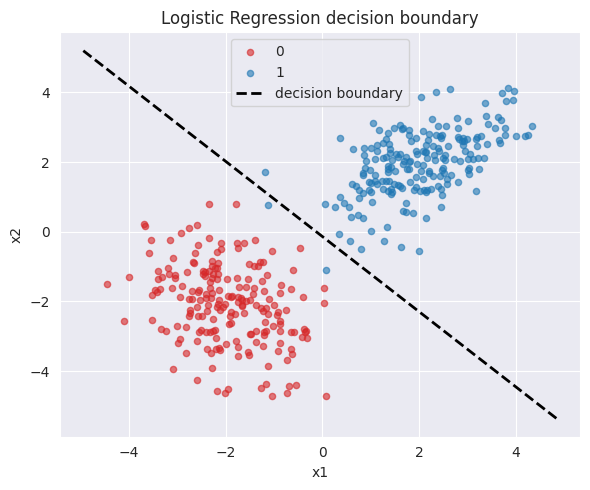

In [19]:
def plot_decision_boundary(
    X: np.ndarray,
    y: np.ndarray,
    w: np.ndarray,
    title: str = "Logistic Regression decision boundary",
) -> None:
    """Plot 2D scatter with the learned linear decision boundary."""
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(X[y == 0, 0], X[y == 0, 1], c="#d62728", s=20, label="0", alpha=0.6)
    ax.scatter(X[y == 1, 0], X[y == 1, 1], c="#1f77b4", s=20, label="1", alpha=0.6)
    x1 = np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 200)
    x2 = -(w[0] + w[1] * x1) / w[2]
    ax.plot(x1, x2, "k--", linewidth=2, label="decision boundary")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()


plot_decision_boundary(X, y, w_learned)

📝 **Bonus analysis**

1. Loss flattens around epoch ~100 (train acc 0.995, data near-separable).
2. η=1.0: oscillates but converges here; would diverge on harder data. η=0.001: way too slow, 200 epochs not enough.
3. SGD: drop the `1/N`, loop over shuffled examples and update `w -= η · (ŷᵢ − yᵢ) · xᵢ` one at a time. Mini-batch = same on a batch with `/batch_size`.

---

## Summary — Running comparison table

Fill in after completing all parts.

In [20]:
results_table = pd.DataFrame([
    {"session": "01", "model": "Majority baseline",       "features": "none",           "val_macro_f1": 0.25,  "test_macro_f1": 0.25},
    # Add your NB results from TP-A
    # Add your LR results from TP-B
])
print(results_table.sort_values("val_macro_f1", ascending=False).to_string(index=False))

session             model features  val_macro_f1  test_macro_f1
     01 Majority baseline     none          0.25           0.25
